In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from feature_eng_exports import data

# Preliminary Data Exploration :

Before moving on to the way features interact with our target variable, i.e `price`, we will first obtain a preliminary overview of the data itself.

In [60]:
eda = data.copy()
eda = eda.reset_index()
del eda['index']

Text(0.5, 1.0, 'Top 10 Models by Frequency')

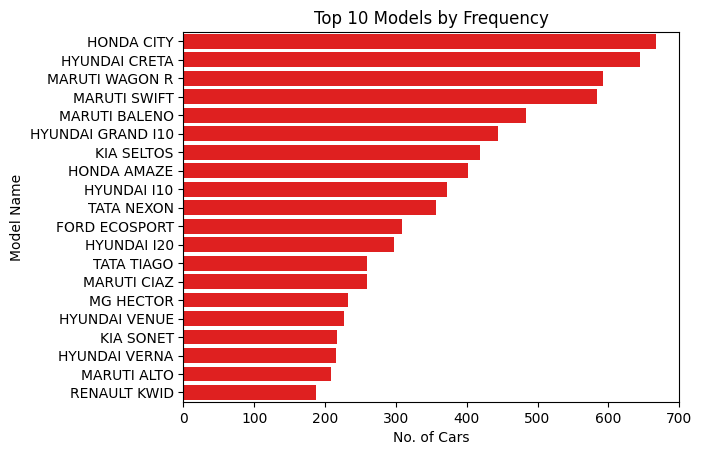

In [61]:
# Most Common Model :

top_n = eda['model'].value_counts()[:20].index
sns.countplot(eda['model'], order=top_n,color='red')

plt.xlabel('No. of Cars')
plt.ylabel('Model Name')
plt.title('Top 10 Models by Frequency')


Text(0.5, 1.0, 'Most Common Brands')

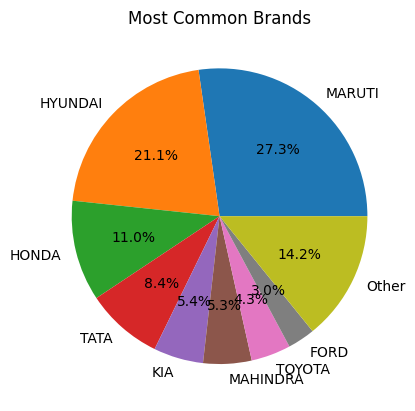

In [62]:
# Pie Chart Representing most common brands :

eda['brand'] = eda['model'].apply(lambda x: x.split(' ')[0])
sub = eda['brand'].value_counts()[:8]
sub['Other'] = eda['brand'].value_counts()[8:].sum()


plt.pie(sub, labels=sub.index, autopct="%1.1f%%")
plt.title('Most Common Brands')


# Interaction of Variables with Price :

Text(0.5, 0, 'Price')

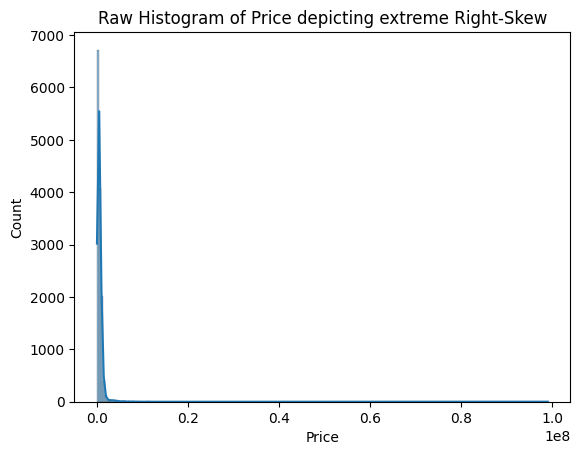

In [63]:
sns.histplot(eda['price'], kde=True)
plt.title('Raw Histogram of Price depicting extreme Right-Skew')
plt.xlabel('Price')

Text(0.5, 0, 'Price')

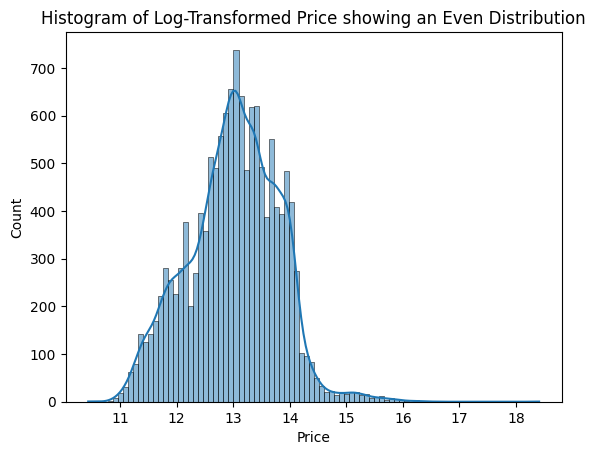

In [64]:
# Visualisation of price
sns.histplot(np.log1p(eda['price']), kde=True)
plt.title('Histogram of Log-Transformed Price showing an Even Distribution')
plt.xlabel('Price')

In [65]:
eda['log_price'] = np.log1p(eda['price'])

In [66]:
eda.columns

Index(['model', 'price', 'price_score', 'plate', 'Reg. year', 'Fuel',
       'KM driven', 'Transmission', 'Engine capacity', 'Ownership',
       'Make year', 'Insurance type', 'Source', 'variant', 'car_age',
       'reg_age', 'ngt_life', 'ngt_critical', 're_register', 'km_per_year',
       'is_luxury_brand', 'ownership_strength', 'Segment', 'brand',
       'log_price'],
      dtype='object')

Text(0.5, 1.0, "Heatmap of Pearson's Correlation Price and it's Independent Variables")

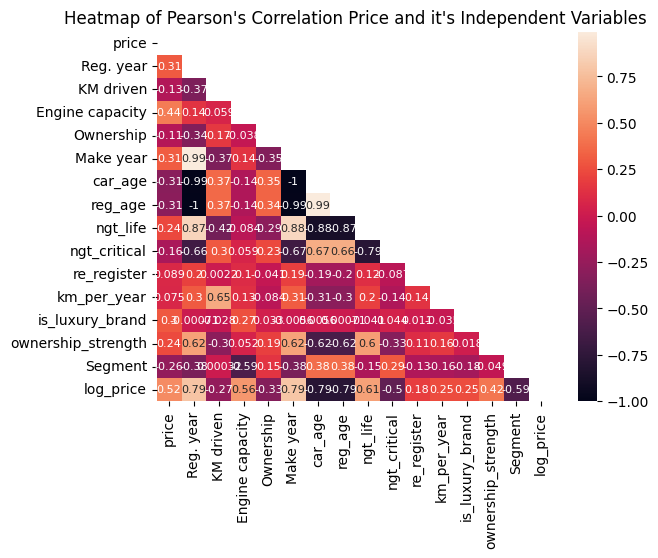

In [67]:
eda_num = eda.select_dtypes(['number','bool','float'])
corr_p = eda_num.corr()
matrix = np.triu(corr_p) # upper-triangle of corr matrix

sns.heatmap(corr_p, annot=True, mask=matrix, annot_kws={'size':8})
plt.title("Heatmap of Pearson's Correlation Price and it's Independent Variables")


In [68]:
corr_p['log_price']

price                 0.515494
Reg. year             0.787614
KM driven            -0.267860
Engine capacity       0.564652
Ownership            -0.331989
Make year             0.792139
car_age              -0.792139
reg_age              -0.787614
ngt_life              0.611998
ngt_critical         -0.496761
re_register           0.183765
km_per_year           0.247962
is_luxury_brand       0.246608
ownership_strength    0.417607
Segment              -0.587186
log_price             1.000000
Name: log_price, dtype: float64

Text(0.5, 1.0, 'Depreciaion of Price with Increase in Car Age')

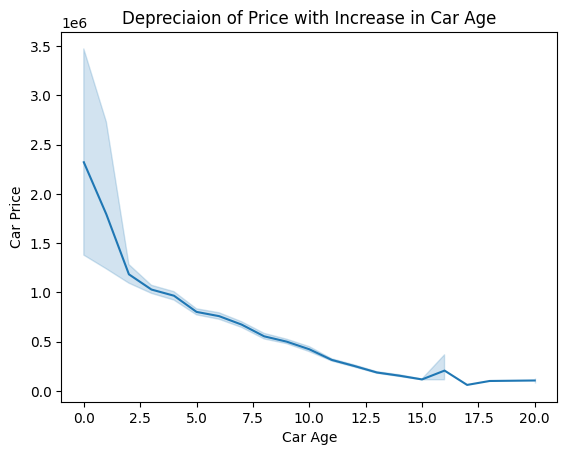

In [69]:
# Car Age v/s Prices
sns.lineplot(data=eda, x=eda['car_age'], y=eda['price'])

plt.xlabel('Car Age')
plt.ylabel('Car Price')
plt.title('Depreciaion of Price with Increase in Car Age')

The above visualisation provides us with a depreciation curve signalling that as the Age of the Car increases, its price in the Used Car Market decreases.

Text(0, 0.5, 'Price of Car')

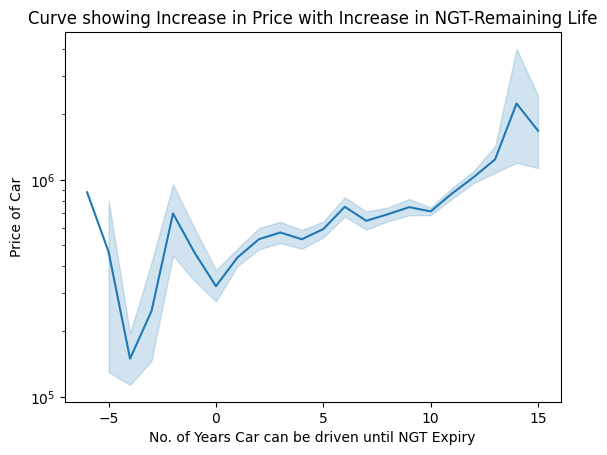

In [70]:
del_subset = eda[eda.re_register == True]

sns.lineplot(data=del_subset, x=del_subset['ngt_life'], y=del_subset['price'])
plt.yscale('log')
plt.title("Curve showing Increase in Price with Increase in NGT-Remaining Life")
plt.xlabel('No. of Years Car can be driven until NGT Expiry')
plt.ylabel('Price of Car')

Text(0.5, 0, 'Transmission Mode')

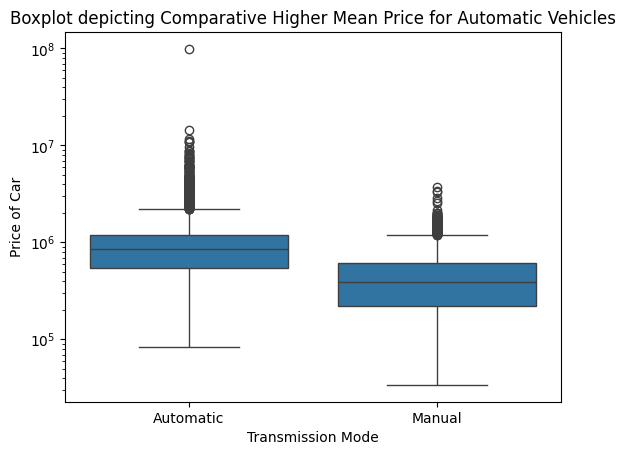

In [71]:
# Transmission v/s Price :
sns.boxplot(x=eda['Transmission'],y=eda['price'])
plt.yscale("log")
plt.title('Boxplot depicting Comparative Higher Mean Price for Automatic Vehicles')
plt.ylabel('Price of Car')
plt.xlabel('Transmission Mode')

Text(0, 0.5, 'Car Price')

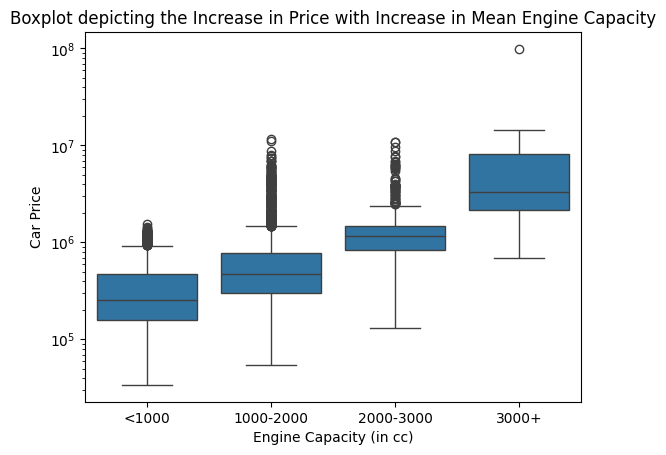

In [72]:
eng_labels = ['<1000', '1000-2000', '2000-3000', '3000+']
eng_bins = [0,1000,2000,3000,10000]
eda['engine_cat'] = pd.cut(eda['Engine capacity'], bins = eng_bins, labels=eng_labels)

sns.boxplot(data=eda,x=eda['engine_cat'], y=eda['price'])
plt.yscale('log')
plt.title('Boxplot depicting the Increase in Price with Increase in Mean Engine Capacity')
plt.xlabel('Engine Capacity (in cc)')
plt.ylabel('Car Price')

Text(0, 0.5, 'Car Price')

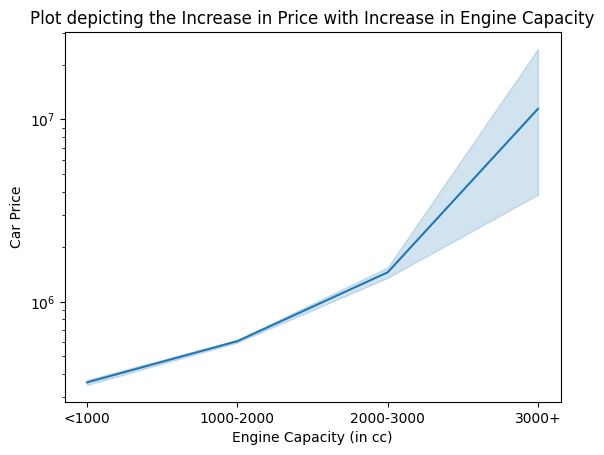

In [73]:
sns.lineplot(data=eda,x=eda['engine_cat'], y=eda['price'])
plt.yscale('log')

plt.title('Plot depicting the Increase in Price with Increase in Engine Capacity')
plt.xlabel('Engine Capacity (in cc)')
plt.ylabel('Car Price')

Text(0, 0.5, 'Car Price')

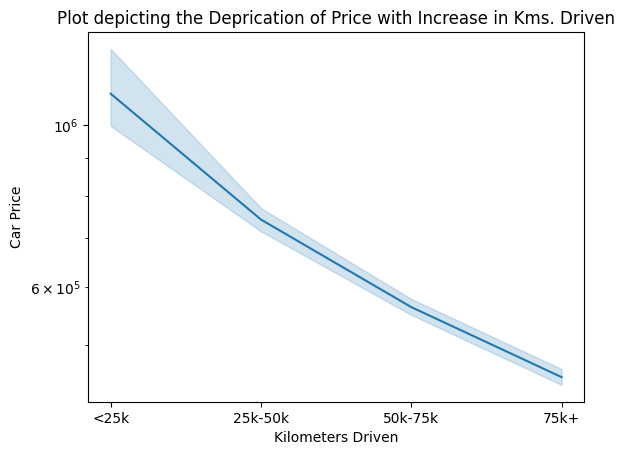

In [74]:
km_labels = ['<25k', '25k-50k', '50k-75k', '75k+']
km_bins = [0,25000,50000,75000,100000000]
eda['km_cat'] = pd.cut(eda['KM driven'], bins = km_bins, labels=km_labels)

sns.lineplot(data=eda,x=eda['km_cat'], y=eda['price'])
plt.yscale('log')
plt.title('Plot depicting the Deprication of Price with Increase in Kms. Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Car Price')

# Testing the Strength of Engineered Variables :

Our Engineered Variables to be tested are :

- `ngt_critical`
- `re_register`
- `is_luxury_brand`


Text(0, 0.5, 'Price of Car')

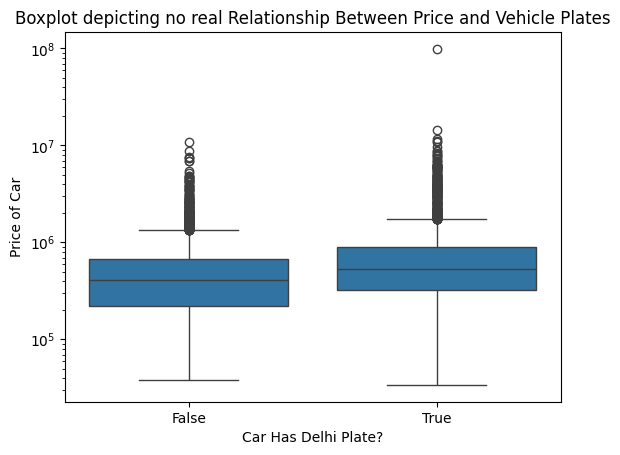

In [75]:
# Re-Registration v/s Price :
sns.boxplot(x=eda['re_register'],y=eda['price'])
plt.yscale("log")
plt.title('Boxplot depicting no real Relationship Between Price and Vehicle Plates')
plt.xlabel('Car Has Delhi Plate?')
plt.ylabel('Price of Car')

Text(0, 0.5, 'Car Price')

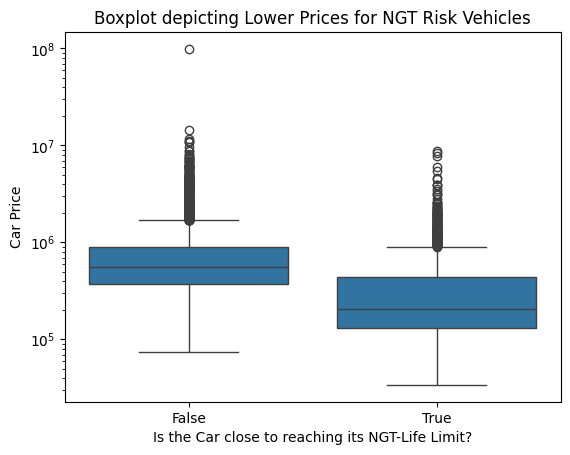

In [76]:
# NGT-Critical v/s Price :
sns.boxplot(x=eda['ngt_critical'],y=eda['price'])
plt.yscale("log")
plt.title('Boxplot depicting Lower Prices for NGT Risk Vehicles')
plt.xlabel('Is the Car close to reaching its NGT-Life Limit?')
plt.ylabel('Car Price')

Text(0, 0.5, 'Car Price')

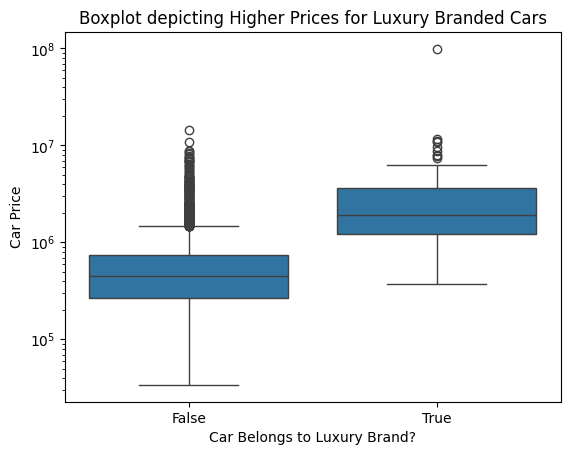

In [77]:
# Luxury Brand v/s Price :
sns.boxplot(x=eda['is_luxury_brand'],y=eda['price'])
plt.yscale("log")
plt.title('Boxplot depicting Higher Prices for Luxury Branded Cars')
plt.xlabel('Car Belongs to Luxury Brand?')
plt.ylabel('Car Price')

# K-Prototypes Segmentation :

In [78]:
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

In [79]:
df_cluster = data[['Fuel', 'Transmission','is_luxury_brand','Engine capacity','Make year']].dropna()
cat_cols = [0,1,2]
num_cols = ['Engine capacity', 'Make year']

In [80]:
# Scaling numeric features :
scaler = StandardScaler()
df_cluster[num_cols] = scaler.fit_transform(df_cluster[num_cols])

In [81]:
# Transforming to a numpy matrix :
df_matrix = df_cluster.to_numpy()

In [82]:
k = 8
cost = []
for i in range(1,8):
    kpr = KPrototypes(n_clusters=i,n_init=7,init='Cao', random_state=42, 
                      n_jobs=-1)
    clusters = kpr.fit_predict(df_matrix, categorical=cat_cols)
    cost.append(kpr.cost_)


Text(0, 0.5, 'Cost')

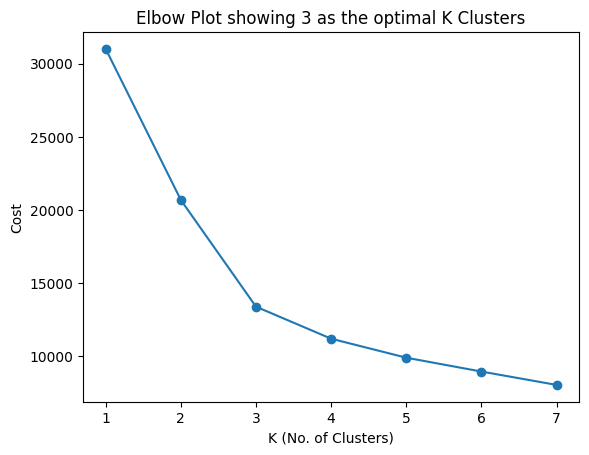

In [83]:
plt.plot(np.arange(1,8),cost,marker='o')
plt.title('Elbow Plot showing 3 as the optimal K Clusters')
plt.xlabel('K (No. of Clusters)')
plt.ylabel('Cost')

In [84]:
kpr4 = KPrototypes(n_clusters=4,n_init=7,init='Cao', random_state=42, 
                      n_jobs=-1)
clusters4 = kpr4.fit_predict(df_matrix, categorical=cat_cols)


In [85]:
data['Segment'] = clusters4
eda['Segment'] = clusters4
data.head()

,model,price,price_score,plate,Reg. year,Fuel,KM driven,Transmission,Engine capacity,Ownership,...,variant,car_age,reg_age,ngt_life,ngt_critical,re_register,km_per_year,is_luxury_brand,ownership_strength,Segment
0,JEEP COMPASS,850000.0,STEAL DEAL,DL-10,2020,Petrol,116562,Automatic,1368.0,1,...,LONGITUDE PLUS,6,6,9,False,False,19427.00,False,0.166667,2
1,MAHINDRA XUV500,451000.0,FAIR PRICE,DL-10,2016,Diesel,238933,Automatic,1997.0,1,...,W6 9,10,10,0,True,False,23893.30,False,0.100000,0
2,HYUNDAI EON,84000.0,STEAL DEAL,UP-15,2013,CNG,94507,Manual,814.0,2,...,D-LITE,14,13,1,True,True,6750.50,False,0.142857,3
3,HYUNDAI I20,181000.0,STEAL DEAL,DL-10,2013,CNG,120121,Manual,1197.0,2,...,SPORTZ,13,13,2,True,False,9240.08,False,0.153846,3
4,HONDA CITY,307000.0,STEAL DEAL,DL-4C,2014,Petrol,77884,Manual,1497.0,2,...,SV,12,12,3,True,False,6490.33,False,0.166667,3


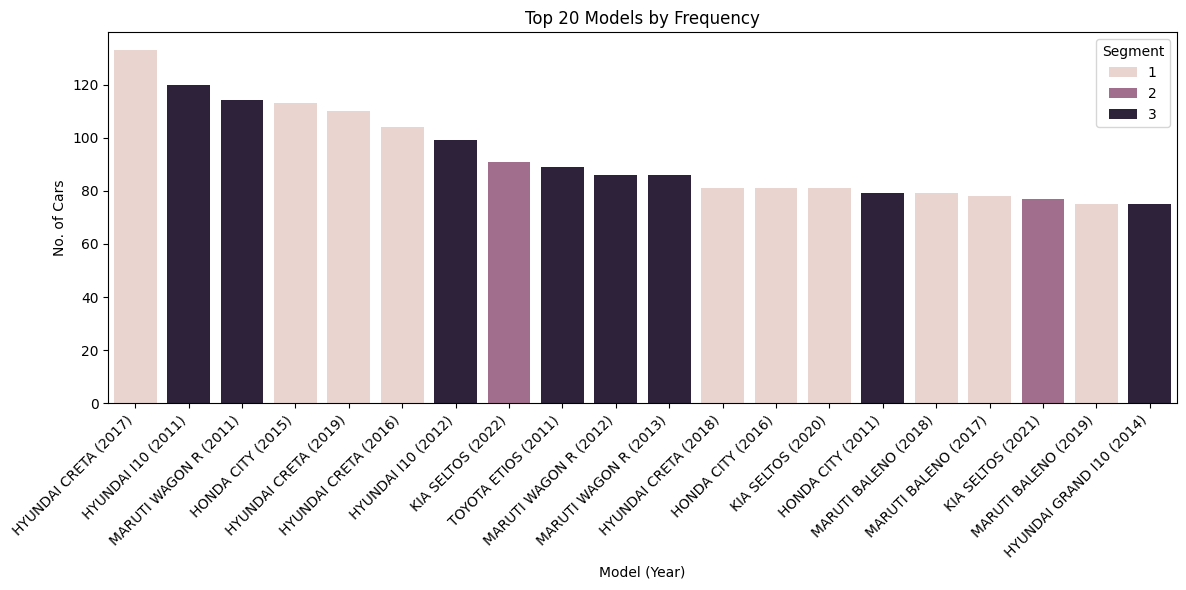

In [86]:
top_20_data = (
    eda.groupby(['model', 'Make year', 'Segment'])
    .size()
    .reset_index(name='No. of Cars')
    .sort_values(by='No. of Cars', ascending=False)
    .head(20)
)

# 2. Create a combined label for the x-axis so you can see the year
top_20_data['Model_Year'] = top_20_data['model'] + " (" + top_20_data['Make year'].astype(str) + ")"

# 3. Plot using barplot (avoids overlap bugs and gives 1 distinct color per segment)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_20_data, 
    x='Model_Year', 
    y='No. of Cars', 
    hue='Segment', 
    dodge=False
)

# 4. Corrected axis labels and title to match the top 20 slice
plt.xlabel('Model (Year)')
plt.ylabel('No. of Cars')
plt.title('Top 20 Models by Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [87]:
# Labelling the clusters :

seg_gb = data.groupby('Segment')['model'].value_counts().to_frame()
print(seg_gb.loc[2].index[:30])

Index(['KIA SELTOS', 'TATA NEXON', 'KIA SONET', 'MARUTI BALENO',
       'HYUNDAI CRETA', 'HYUNDAI VENUE', 'MARUTI SWIFT', 'TATA TIAGO',
       'MARUTI GRAND VITARA', 'TATA PUNCH', 'MG HECTOR', 'MARUTI WAGON-R',
       'TATA ALTROZ', 'HONDA CITY', 'NISSAN MAGNITE', 'HYUNDAI I20',
       'KIA CARENS', 'MARUTI XL6', 'MARUTI BREZZA', 'MG ASTOR',
       'RENAULT TRIBER', 'HYUNDAI GRAND I10', 'HONDA AMAZE', 'HYUNDAI AURA',
       'HYUNDAI VERNA', 'MAHINDRA XUV300', 'VOLKSWAGEN TAIGUN', 'TATA TIGOR',
       'TOYOTA GLANZA', 'MARUTI ERTIGA'],
      dtype='object', name='model')


- perform an analysis on the outliers, telling why they behave the way they do, any errenous values
- give descriptions for each plot 


# Outlier Analysis :

In [88]:
data['price'].describe(percentiles=[0.95,0.99]).astype('int')

count       13562
mean       617970
std       1063138
min         34000
50%        462000
95%       1350000
99%       3300000
max      99000000
Name: price, dtype: int64

The 95th percentile of prices reaches 13 lakh. This implies that 95% of car prices are below this 13 lakh figure, implying that the used car market is skewed towards cheaper vehicles, with more luxury cars being a rarity. In this market, cars that are priced high become outliers, so a proper analysis of such data points must be undertaken to firstly detect any errenous listings and secondly to understand the factors that influence highly priced cars in the used car market. 

In [89]:
data['KM driven'].describe(percentiles=[0.95,0.99]).astype('int')


count      13562
mean       71265
std        49324
min            1
50%        65416
95%       145491
99%       204237
max      1290000
Name: KM driven, dtype: int64

Similar to prices, an analysis of the KM driven column is also performed. Here, the minimum distance travelled is a car with 1 KM, which is odd. This data point must pe inspected. The other values are as expected.

In [90]:
# Price :
data.nlargest(n=10, columns='price')

,model,price,price_score,plate,Reg. year,Fuel,KM driven,Transmission,Engine capacity,Ownership,...,variant,car_age,reg_age,ngt_life,ngt_critical,re_register,km_per_year,is_luxury_brand,ownership_strength,Segment
14202,ROLLS-ROYCE CULLINAN,99000000.0,NaN,Mumbai,2025,Petrol,350,Automatic,6750.0,1,...,SERIES II,1,1,14,False,True,350.00,True,1.000,0
16183,BMW XM,14500000.0,NaN,Almora,2024,Petrol,26000,Automatic,4395.0,1,...,XDRIVE,2,2,13,False,True,13000.00,False,0.500,0
14338,LAND ROVER DEFENDER,11700000.0,NaN,Chandigarh,2025,Petrol,25000,Automatic,1997.0,1,...,L 110 X-DYNAMIC HSE,1,1,14,False,True,25000.00,True,1.000,0
15240,LAND ROVER DEFENDER,11100000.0,NaN,Faridabad,2024,Petrol,24000,Automatic,1997.0,1,...,L 110 X-DYNAMIC HSE,2,2,13,False,True,12000.00,True,0.500,0
13434,BMW X7,10900000.0,NaN,Faridabad,2024,Petrol,28310,Automatic,2998.0,1,...,XDRIVE40I M SPORT,2,2,13,False,True,14155.00,False,0.500,0
15513,MERCEDES-BENZ S-CLASS,10800000.0,NaN,New Delhi,2022,Petrol,20000,Automatic,2999.0,1,...,S450 4MIC BSVI,4,4,11,False,False,5000.00,True,0.250,0
16460,MERCEDES-BENZ S-CLASS,9600000.0,NaN,HR98,2022,Diesel,18699,Automatic,2925.0,1,...,S 350D BSVI,4,4,6,False,True,4674.75,True,0.250,0
13705,TOYOTA LAND CRUISER 200,8800000.0,NaN,Chandigarh,2018,Diesel,260000,Automatic,4461.0,1,...,VX,8,8,2,True,True,32500.00,False,0.125,0
16196,BMW 7 SERIES,8800000.0,NaN,Lucknow,2022,Diesel,44000,Automatic,2993.0,1,...,730LD DPE SIGNURE,4,4,6,False,True,11000.00,False,0.250,0
14030,VOLVO XC90,8790000.0,NaN,New Delhi,2025,Petrol,5000,Automatic,1969.0,1,...,B5 AWD MILD HYBRID ULTRA,1,1,14,False,False,5000.00,True,1.000,0


As observed from the data, it is evident that these vehicles :
- belong to luxury brands/variants
- have high engine capacity compared to the mean
- have less KM. driven
- have newer Make Years, making their NGT life high.

These factors explain why these vehicles are priced the way they are. These are not errenous observations, but rather genuine data points with explainable variables.

In [91]:
data[data['KM driven'] < 100]

,model,price,price_score,plate,Reg. year,Fuel,KM driven,Transmission,Engine capacity,Ownership,...,variant,car_age,reg_age,ngt_life,ngt_critical,re_register,km_per_year,is_luxury_brand,ownership_strength,Segment
1108,MARUTI CELERIO,488000.0,FAIR PRICE,DL-2C,2026,Petrol,90,Manual,998.0,1,...,LXI,1,0,14,False,False,90.00,False,1.0,2
2084,HYUNDAI VENUE,814000.0,FAIR PRICE,DL-5C,2024,Petrol,10,Manual,1197.0,1,...,S,2,2,13,False,False,5.00,False,0.5,2
4132,MARUTI GRAND VITARA,1010000.0,STEAL DEAL,UP-15,2025,Petrol,65,Manual,1462.0,1,...,SIGMA SMART HYBRID,2,1,13,False,True,32.50,False,0.5,2
6705,KIA SONET,680000.0,STEAL DEAL,DL-14,2020,Diesel,1,Automatic,1493.0,3,...,GTX PLUS,6,6,4,False,False,0.17,False,0.5,1


3 of these cars have recent Make Years, which explain why they have been driven for such a less amount of time. However, the FIAT is an old car with abnormally low KM driven. This is almost certainly an errenous value.

In [ ]:
# data.drop(570,axis='index', inplace=True)

KeyError: '[570] not found in axis'

- improve labels and diagrams